In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
REPO_ROOT = "../../.."
PRITHVI_MODEL_PATH = "../model"

sys.path.append(PRITHVI_MODEL_PATH)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Prithvi path exists:", os.path.exists(PRITHVI_MODEL_PATH))
print("Absolute Prithvi path:", os.path.abspath(PRITHVI_MODEL_PATH))

Torch version: 2.2.2
CUDA available: False
Prithvi path exists: True
Absolute Prithvi path: /Users/andrespadronquintana/Desktop/ESTANCIA/PROY/Earth-Embedding-Benchmarks-for-Geospatial-Prediction/models/prithvi/model


In [3]:
import os

for file in sorted(os.listdir(PRITHVI_MODEL_PATH)):
    print(file)

.DS_Store
.git
.gitignore
CITATION.cff
LICENSE
README.md
configs
data_splits
exploration.ipynb
geospatial_fm
geospatial_fm.egg-info
hls-gfm
model_inference.py
models
setup.py


In [4]:
for root, dirs, files in os.walk(PRITHVI_MODEL_PATH):
    if "backbones" in root:
        print(root)

In [5]:
import glob

files = glob.glob("../model/**/*.py", recursive=True)

len(files)

11

In [6]:
for f in files:
    if "vit" in f.lower() or "transformer" in f.lower():
        print(f)

In [7]:
import os

for root, dirs, files in os.walk("../model/geospatial_fm"):
    level = root.replace("../model/geospatial_fm", "").count(os.sep)

    if level <= 2:
        print(root)

        for f in files:
            print("   ", f)

../model/geospatial_fm
    datasets.py
    __init__.py
    geospatial_pipelines.py
    geospatial_fm.py
    temporal_encoder_decoder.py
../model/geospatial_fm/__pycache__
    __init__.cpython-39.pyc
    geospatial_fm.cpython-39.pyc


In [8]:
for root, dirs, files in os.walk("../model/hls-gfm"):
    level = root.replace("../model/hls-gfm", "").count(os.sep)

    if level <= 2:
        print(root)

        for f in files:
            print("   ", f)

../model/hls-gfm
    README.md


In [9]:
with open("../model/geospatial_fm/geospatial_fm.py", "r") as f:
    print(f.read()[:4000])

# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
# --------------------------------------------------------
# References:
# timm: https://github.com/rwightman/pytorch-image-models/tree/master/timm
# DeiT: https://github.com/facebookresearch/deit
# --------------------------------------------------------

import numpy as np
import torch
import torch.nn as nn
from einops import rearrange
from mmcv.runner import load_checkpoint
from mmseg.models.builder import BACKBONES, NECKS
from timm.models.layers import to_2tuple
from timm.models.vision_transformer import Block
from typing import List


def _convTranspose2dOutput(
    input_size: int,
    stride: int,
    padding: int,
    dilation: int,
    kernel_size: int,
    output_padding: int,
):
    """
    Calculate the output size of a ConvTranspose2d.
    Taken from: https://pytorch.org/docs/sta

In [10]:
with open("../model/geospatial_fm/temporal_encoder_decoder.py", "r") as f:
    print(f.read()[:5000])

# Copyright (c) OpenMMLab. All rights reserved.
import torch
import torch.nn as nn
import torch.nn.functional as F

from mmseg.core import add_prefix
from mmseg.ops import resize
from mmseg.models import builder
from mmseg.models.builder import SEGMENTORS
from mmseg.models.segmentors.base import BaseSegmentor
from mmseg.models.segmentors.encoder_decoder import EncoderDecoder


@SEGMENTORS.register_module()
class TemporalEncoderDecoder(EncoderDecoder):
    """Encoder Decoder segmentors.

    EncoderDecoder typically consists of backbone, neck, decode_head, auxiliary_head.
    Note that auxiliary_head is only used for deep supervision during training,
    which could be dumped during inference.

    The backbone should return plain embeddings.
    The neck can process these to make them suitable for the chosen heads.
    The heads perform the final processing that will return the output.
    """

    def __init__(self,
                 backbone,
                 decode_head,
            

In [11]:
import re

with open("../model/geospatial_fm/geospatial_fm.py") as f:
    text = f.read()

for m in re.finditer(r"class\s+\w+", text):
    print(m.group())

class PatchEmbed
class Norm2d
class GeospatialNeck
class ConvTransformerTokensToEmbeddingNeck
class TemporalViTEncoder
class defines


In [12]:
for m in re.finditer(r"def\s+forward", text):
    print(m.group())

def forward
def forward
def forward
def forward
def forward


In [13]:
import importlib.util

geospatial_fm_file = "../model/geospatial_fm/geospatial_fm.py"

spec = importlib.util.spec_from_file_location(
    "geospatial_fm_raw",
    geospatial_fm_file
)

geospatial_fm_raw = importlib.util.module_from_spec(spec)

In [14]:
from prithvi_encoder_minimal import TemporalViTEncoder

encoder = TemporalViTEncoder(
    img_size=224,
    patch_size=16,
    num_frames=1,
    tubelet_size=1,
    in_chans=6,
    embed_dim=1024,
    depth=24,
    num_heads=16
)

encoder.eval()

print("Prithvi minimal encoder loaded")

Prithvi minimal encoder loaded


In [15]:
x = torch.randn(1, 6, 1, 224, 224)

with torch.no_grad():
    tokens = encoder(x)

print(tokens.shape)

torch.Size([1, 197, 1024])


In [16]:
embedding = tokens[:, 0, :]

print(embedding.shape)

torch.Size([1, 1024])


In [17]:
# Extracción completa desde google earth engine

In [18]:
from pathlib import Path
import rasterio

DATA_DIR = Path("data")

tif_path = DATA_DIR / "cdmx_prithvi_patch.tif"

print(tif_path)

data/cdmx_prithvi_patch.tif


In [19]:
with rasterio.open(tif_path) as src:
    image = src.read()

print(image.shape)

(6, 225, 237)


In [20]:
import torch
import torch.nn.functional as F

image = image.astype("float32") / 10000.0

x = torch.from_numpy(image)

print("Original:", x.shape)

x = x.unsqueeze(0)

x = F.interpolate(
    x,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

x = x.unsqueeze(2)

print("Prithvi input:", x.shape)

Original: torch.Size([6, 225, 237])
Prithvi input: torch.Size([1, 6, 1, 224, 224])


In [21]:
with torch.no_grad():
    tokens = encoder(x)

embedding = tokens[:, 0, :]

print(tokens.shape)
print(embedding.shape)

torch.Size([1, 197, 1024])
torch.Size([1, 1024])


In [22]:
import numpy as np

embedding_np = embedding.squeeze().cpu().numpy()

print(embedding_np.shape)

np.save(
    "cdmx_prithvi_embedding.npy",
    embedding_np
)

print("Embedding saved!")

(1024,)
Embedding saved!


In [23]:
embedding_np[:20]

array([ 0.20624615,  0.28912252,  0.30710757,  0.97737765,  0.7419774 ,
       -1.3672591 ,  0.01586544,  0.12078161, -1.3619999 ,  0.6983266 ,
        0.924083  ,  0.8404382 , -0.5048964 , -0.0694643 , -0.08122832,
        0.80349666, -1.0734774 , -0.65643555,  0.16008568, -0.02762302],
      dtype=float32)

In [24]:
embedding_np.mean(), embedding_np.std()

(3.7252903e-09, 0.99999976)

In [25]:
embedding_np.min(), embedding_np.max()

(-3.2639995, 3.4519522)

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn.functional as F

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

cities = ["cdmx", "guadalajara", "monterrey", "merida", "oaxaca"]

rows = []

for city in cities:
    tif_path = DATA_DIR / f"{city}_prithvi_patch.tif"

    with rasterio.open(tif_path) as src:
        image = src.read()

    image = image.astype("float32") / 10000.0

    x = torch.from_numpy(image)
    x = x.unsqueeze(0)

    x = F.interpolate(
        x,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    x = x.unsqueeze(2)

    with torch.no_grad():
        tokens = encoder(x)

    embedding = tokens[:, 0, :].squeeze().cpu().numpy()

    np.save(
        OUTPUT_DIR / f"{city}_prithvi_embedding.npy",
        embedding
    )

    row = {
        "city": city,
        "lat": None,
        "lon": None
    }

    for i, value in enumerate(embedding):
        row[f"dim_{i}"] = value

    rows.append(row)

    print(city, embedding.shape)

prithvi_df = pd.DataFrame(rows)

prithvi_df.to_csv(
    OUTPUT_DIR / "prithvi_mexico_embeddings.csv",
    index=False
)

prithvi_df.head()

cdmx (1024,)
guadalajara (1024,)
monterrey (1024,)
merida (1024,)
oaxaca (1024,)


,city,lat,lon,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_1014,dim_1015,dim_1016,dim_1017,dim_1018,dim_1019,dim_1020,dim_1021,dim_1022,dim_1023
0,cdmx,None,None,0.206246,0.289123,0.307108,0.977378,0.741977,-1.367259,0.015865,...,-0.304138,1.441194,-0.775012,-1.571041,0.135598,0.874485,-1.139991,1.046591,-0.993112,-0.016343
1,guadalajara,None,None,0.043279,0.303844,0.566758,0.924042,0.886283,-1.295089,0.149522,...,-0.248270,1.504396,-0.831511,-1.632637,0.082976,1.059444,-1.137640,1.138668,-0.989548,0.002440
2,monterrey,None,None,0.027152,0.281037,0.526203,0.956223,0.884059,-1.347385,0.109545,...,-0.210063,1.440427,-0.845787,-1.595323,0.070750,1.077416,-1.060644,1.078625,-1.016025,0.002464
3,merida,None,None,-0.095386,0.239310,0.911142,0.744969,1.088402,-1.193904,0.174232,...,-0.290639,1.639569,-0.887304,-1.737655,0.008896,1.082138,-1.070341,1.169794,-1.048091,0.036914
4,oaxaca,None,None,0.193485,0.276752,0.396114,0.908745,0.777955,-1.322087,0.050931,...,-0.376121,1.506312,-0.774200,-1.615375,0.113910,0.860790,-1.151745,1.067034,-1.016688,-0.007478


In [27]:
import numpy as np

for city in prithvi_df.city:
    emb = np.load(f"outputs/{city}_prithvi_embedding.npy")
    print(city, emb.mean(), emb.std())

cdmx 3.7252903e-09 0.99999976
guadalajara -1.8626451e-09 0.99999976
monterrey 2.0489097e-08 0.9999997
merida -1.4901161e-08 0.99999976
oaxaca 9.313226e-09 0.99999976


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

X = prithvi_df.filter(regex="dim_").values

sim = cosine_similarity(X)

import pandas as pd

pd.DataFrame(
    sim,
    index=prithvi_df.city,
    columns=prithvi_df.city
)

city,cdmx,guadalajara,monterrey,merida,oaxaca
city,,,,,
cdmx,1.000000,0.995780,0.996181,0.976030,0.998622
guadalajara,0.995780,1.000000,0.999440,0.990725,0.997859
monterrey,0.996181,0.999440,1.000001,0.988447,0.997115
merida,0.976030,0.990725,0.988447,1.000000,0.984389
oaxaca,0.998622,0.997859,0.997115,0.984389,1.000000


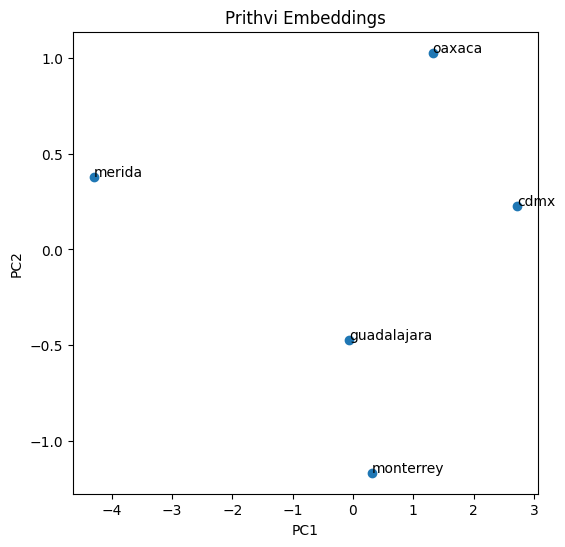

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = prithvi_df.filter(regex="dim_").values

pca = PCA(n_components=2)

Z = pca.fit_transform(X)

plt.figure(figsize=(6,6))

plt.scatter(Z[:,0], Z[:,1])

for i, city in enumerate(prithvi_df.city):
    plt.text(Z[i,0], Z[i,1], city)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Prithvi Embeddings")
plt.show()

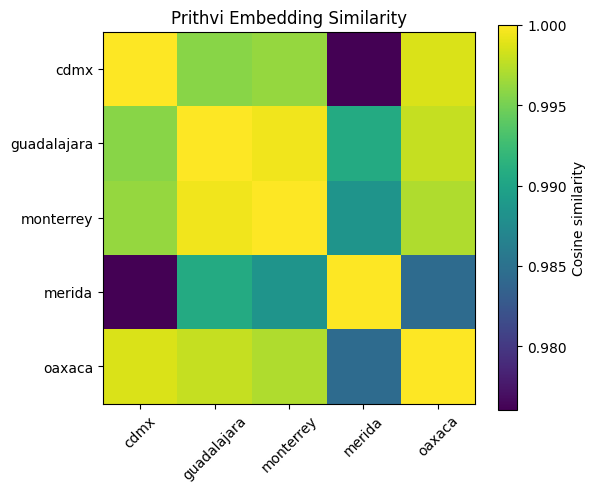

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

X = prithvi_df.filter(regex="dim_").values

similarity = cosine_similarity(X)

plt.figure(figsize=(6,5))

plt.imshow(similarity, cmap="viridis")

plt.xticks(range(len(prithvi_df)), prithvi_df.city, rotation=45)
plt.yticks(range(len(prithvi_df)), prithvi_df.city)

plt.colorbar(label="Cosine similarity")
plt.title("Prithvi Embedding Similarity")

plt.show()

In [31]:
import pandas as pd

pd.DataFrame(
    similarity,
    index=prithvi_df.city,
    columns=prithvi_df.city
)

city,cdmx,guadalajara,monterrey,merida,oaxaca
city,,,,,
cdmx,1.000000,0.995780,0.996181,0.976030,0.998622
guadalajara,0.995780,1.000000,0.999440,0.990725,0.997859
monterrey,0.996181,0.999440,1.000001,0.988447,0.997115
merida,0.976030,0.990725,0.988447,1.000000,0.984389
oaxaca,0.998622,0.997859,0.997115,0.984389,1.000000
